# Wordle: Gemma + LoRA + ES

Train a **linear head** on a Hugging Face causal LM with **Evolution Strategies**. This Week 11 notebook keeps the full **`google/gemma-3-1b-it`** path available, but now defaults to a **smoke-test profile** so you can verify the workflow quickly before committing to a long run. Switch `RUN_PROFILE` in §2 to move from fast validation to the fuller Gemma setup.

**Also:** Richer prompts with **structured constraints** from feedback; optional **supervised warm-start** (cross-entropy to the secret word; label only, not in the prompt).

**Requires:** `torch`, `transformers>=4.50.0`, `jinja2>=3.1.0` for chat-template models such as Gemma, `numpy`, `matplotlib`. **`pip install peft`** only if `USE_LORA=True` in §2. First run downloads HF weights.

## 1. Environment and imports

`peft` is **not** imported here (only needed for `USE_LORA=True`). Install it yourself if you enable LoRA.

**If you see `apply_chat_template requires jinja2>=3.1.0`:** run `python -m pip install -U 'jinja2>=3.1.0'` in the active notebook environment, then restart the kernel.

**If you see `unexpected keyword argument 'normalize_gradient'`:** restart the kernel and run this cell again, or rely on `importlib.reload` below (re-run this cell after editing `src/es_wordle.py`).

In [15]:
import os
import sys
import importlib
from pathlib import Path

import numpy as np
import torch

# Fall back to standard HF downloads; Xet caused import/download issues in this env.
os.environ.setdefault("HF_HUB_DISABLE_XET", "1")

# Repo root + src on path (works from `notebooks/` or project root)
_here = Path.cwd().resolve()
ROOT = _here.parent if _here.name == "notebooks" else _here
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import wordle_env
importlib.reload(wordle_env)
from wordle_env import load_wordle_environment
from wordle_gpt2_policy import WordleGPT2Policy, TRANSFORMERS_AVAILABLE

# Always pick up the latest training/environment code (Jupyter caches imports)
import es_wordle
importlib.reload(es_wordle)
from es_wordle import train_es_wordle

import inspect
_sig = inspect.signature(train_es_wordle)
for _name in ("normalize_gradient", "eval_deterministic"):
    if _name not in _sig.parameters:
        raise RuntimeError(
            f"src/es_wordle.py is missing {_name}. Re-run the import cell after `importlib.reload`, or pull the latest repo."
        )

if not TRANSFORMERS_AVAILABLE:
    raise ImportError("Install transformers: pip install transformers")


def choose_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    mps_backend = getattr(torch.backends, "mps", None)
    if mps_backend is not None and mps_backend.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def default_model_load_kwargs(device: torch.device) -> tuple[dict, str]:
    if device.type != "cuda":
        return {}, "float32"
    if torch.cuda.is_bf16_supported():
        return {"torch_dtype": torch.bfloat16}, "bfloat16"
    return {"torch_dtype": torch.float16}, "float16"


def _parse_version_tuple(version: str) -> tuple[int, ...]:
    parts = []
    for chunk in version.split("."):
        digits = ""
        for ch in chunk:
            if ch.isdigit():
                digits += ch
            else:
                break
        if not digits:
            break
        parts.append(int(digits))
    return tuple(parts)


def require_chat_template_support() -> None:
    try:
        import jinja2
    except ImportError as exc:
        raise ImportError(
            "Chat-template models require `jinja2>=3.1.0`. Install or upgrade it in the active notebook environment with `python -m pip install -U 'jinja2>=3.1.0'`, then restart the kernel."
        ) from exc

    installed = getattr(jinja2, "__version__", "0")
    if _parse_version_tuple(installed) < (3, 1, 0):
        raise ImportError(
            f"Chat-template models require `jinja2>=3.1.0`, but found {installed}. Upgrade it in the active notebook environment with `python -m pip install -U 'jinja2>=3.1.0'`, then restart the kernel."
        )


print("ROOT:", ROOT)
print("es_wordle:", es_wordle.__file__)
print("torch:", torch.__version__, "| cuda:", torch.cuda.is_available())
print("HF_HUB_DISABLE_XET:", os.environ["HF_HUB_DISABLE_XET"])
if torch.cuda.is_available():
    print("cuda_device:", torch.cuda.get_device_name(0))

ROOT: /home/ubuntu/STAT-4830-project-base
es_wordle: /home/ubuntu/STAT-4830-project-base/src/es_wordle.py
torch: 2.11.0+cu126 | cuda: True
HF_HUB_DISABLE_XET: 1
cuda_device: NVIDIA A100-SXM4-80GB


## 2. Hyperparameters

The next cell now supports two profiles:

- **`RUN_PROFILE="smoke"`**: fast validation path using a smaller model and short ES/warm-start settings.
- **`RUN_PROFILE="gemma_full"`**: restores the fuller Week 11 Gemma configuration for a real run.

Additional notes:

- **`MODEL_LOAD_KWARGS`**: automatically picks a GPU-friendly dtype on CUDA (`bfloat16` when supported, else `float16`). CPU stays on `float32`.
- **`USE_CHAT_TEMPLATE`**: stays enabled for Gemma instruction checkpoints and disabled for the smoke-test GPT-2 path.
- **`MOCK_ENV`**: remains `True` by default so validation runs stay bounded and always have the target word in the action set.
- **`N_POP` / `N_ITERATIONS` / `WARM_START_STEPS`**: are profile-controlled so the smoke path stays quick while the Gemma path keeps the heavier settings.
- **`USE_LORA`**: still defaults to `False` so validation only trains the head unless you explicitly enable adapters.

In [16]:
# --- Hyperparameters (switch RUN_PROFILE for longer runs) ---

SEED = 42
RUN_PROFILE = "gemma_full"  # "smoke" or "gemma_full"
DEVICE = choose_device()

MOCK_ENV = False
USE_PRIME_TARGETS = False
USE_LORA = True  # Leave False for validation; enable only if you want PEFT adapters.
LORA_R = 4
RICHER_PROMPT = True
WARM_START_LR = 3e-4
SIGMA = 0.02
ALPHA = 0.12
NORMALIZE_GRADIENT = True
RANK_FITNESS = True
EVAL_DETERMINISTIC = True  # greedy eval: Success % reflects argmax policy (clearer after warm-start)
FITNESS_OBJECTIVE = "win_plus_return"
WIN_FITNESS_SCALE = 8.0

PROFILE_CONFIGS = {
    "smoke": {
        "model_name": "distilgpt2",
        "use_chat_template": False,
        "chat_generation_prompt": False,
        "max_prompt_length": 256,
        "max_vocab": 8,
        "n_eval_episodes": 1,
        "eval_n_episodes": 4,
        "eval_every": 1,
        "warm_start_steps": 12,
        "n_pop": 4,
        "n_iterations": 2,
        "num_train_examples": 128,
        "num_eval_examples": 16,
    },
    "gemma_full": {
        "model_name": "google/gemma-3-1b-it",
        "use_chat_template": True,
        "chat_generation_prompt": True,
        "max_prompt_length": 512,
        "max_vocab": None,
        "n_eval_episodes": 2,
        "eval_n_episodes": 48,
        "eval_every": 1,
        "warm_start_steps": 400,
        "n_pop": 16,
        "n_iterations": 10,
        "num_train_examples": 2000,
        "num_eval_examples": 20,
    },
}

if RUN_PROFILE not in PROFILE_CONFIGS:
    raise ValueError(f"RUN_PROFILE must be one of {sorted(PROFILE_CONFIGS)}, got {RUN_PROFILE!r}")

cfg = PROFILE_CONFIGS[RUN_PROFILE]
MODEL_NAME = cfg["model_name"]
USE_CHAT_TEMPLATE = cfg["use_chat_template"]
if USE_CHAT_TEMPLATE:
    require_chat_template_support()
CHAT_GENERATION_PROMPT = cfg["chat_generation_prompt"]
MAX_PROMPT_LENGTH = cfg["max_prompt_length"]
N_EVAL_EPISODES = cfg["n_eval_episodes"]
EVAL_N_EPISODES = cfg["eval_n_episodes"]
EVAL_EVERY = cfg["eval_every"]
WARM_START_STEPS = cfg["warm_start_steps"]
N_POP = cfg["n_pop"]
N_ITERATIONS = cfg["n_iterations"]
NUM_TRAIN_EXAMPLES = cfg["num_train_examples"]
NUM_EVAL_EXAMPLES = cfg["num_eval_examples"]

# Mock: action space == secret pool only → every episode solvable; ES / eval see real wins.
if MOCK_ENV:
    from wordle_env import MOCK_WORDLE_TARGETS as _MOCK_T
    _MOCK_ACTIONS = len(_MOCK_T)
else:
    _MOCK_ACTIONS = None

MAX_VOCAB = _MOCK_ACTIONS if MOCK_ENV else cfg["max_vocab"]
MODEL_LOAD_KWARGS, MODEL_DTYPE_NAME = default_model_load_kwargs(DEVICE)

import random

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = DEVICE
print(
    f"Profile: {RUN_PROFILE} | Model: {MODEL_NAME} | chat_template: {USE_CHAT_TEMPLATE} | LoRA: {USE_LORA}\n"
    f"  device={device}  model_dtype={MODEL_DTYPE_NAME}  MAX_PROMPT_LENGTH={MAX_PROMPT_LENGTH}  MAX_VOCAB={MAX_VOCAB}\n"
    f"  ES: N_POP={N_POP}  N_ITERATIONS={N_ITERATIONS}  n_eval_episodes={N_EVAL_EPISODES}  "
    f"eval_n_episodes={EVAL_N_EPISODES}  WARM_START_STEPS={WARM_START_STEPS}"
)
if MODEL_LOAD_KWARGS:
    print("model_load_kwargs:", MODEL_LOAD_KWARGS)

Profile: gemma_full | Model: google/gemma-3-1b-it | chat_template: True | LoRA: True
  device=cuda  model_dtype=bfloat16  MAX_PROMPT_LENGTH=512  MAX_VOCAB=None
  ES: N_POP=16  N_ITERATIONS=10  n_eval_episodes=2  eval_n_episodes=48  WARM_START_STEPS=400
model_load_kwargs: {'torch_dtype': torch.bfloat16}


## 3. Build policy and environment

First execution downloads the tokenizer + weights for `MODEL_NAME` into the HF cache.

For `RUN_PROFILE="smoke"`, this should stay quick and use the small GPT-2 path. For `RUN_PROFILE="gemma_full"`, expect a larger download and a much heavier run.

`MODEL_LOAD_KWARGS` now passes a GPU-friendly dtype into the Hugging Face model loader when CUDA is available.

With `include_mock_targets_in_vocab=True` (default), the first actions include all `MOCK_WORDLE_TARGETS` so a random mock secret word is always in the action set.

Set `USE_LORA=True` in §2 for PEFT LoRA — run **`pip install peft`** before this cell. With `USE_LORA=False`, only the head is trained (faster ES).

In [17]:
policy = WordleGPT2Policy(
    model_name=MODEL_NAME,
    use_prime_targets=USE_PRIME_TARGETS,
    max_vocab_size=MAX_VOCAB,
    max_prompt_length=MAX_PROMPT_LENGTH,
    include_mock_targets_in_vocab=True,
    richer_prompt=RICHER_PROMPT,
    use_chat_template=USE_CHAT_TEMPLATE,
    chat_generation_prompt=CHAT_GENERATION_PROMPT,
    use_lora=USE_LORA,
    lora_r=LORA_R,
    model_kwargs=MODEL_LOAD_KWARGS,
).to(device)

from wordle_env import MOCK_WORDLE_TARGETS
assert all(w in policy.words for w in MOCK_WORDLE_TARGETS)

print(f"Trainable (ES): {policy.count_trainable_parameters():,}")
print(f"Total params:   {policy.count_parameters():,}")
print(f"Action dim:     {policy.action_dim}")
print(f"Chat template:  {policy.use_chat_template}")
print(f"Load kwargs:    {MODEL_LOAD_KWARGS or {'torch_dtype': 'float32'}}")

env = load_wordle_environment(
    num_train_examples=NUM_TRAIN_EXAMPLES,
    num_eval_examples=NUM_EVAL_EXAMPLES,
    use_prime_intellect=not MOCK_ENV,
)

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

Trainable (ES): 1,476,474
Total params:   1,001,362,426
Action dim:     634
Chat template:  True
Load kwargs:    {'torch_dtype': torch.bfloat16}
[INFO] verifiers package not installed; using bundled Wordle answer list.
[OK] Local Wordle environment ready (2315 target words).


## 4. Optional supervised warm-start

Random play for 1–4 guesses, then **cross-entropy** toward the secret word (the answer is **not** in the prompt). Set `WARM_START_STEPS = 0` to skip.

In [18]:
# from wordle_gpt2_warmstart import supervised_warm_start_wordle

# if WARM_START_STEPS > 0:
#     ws = supervised_warm_start_wordle(
#         policy,
#         env,
#         n_steps=WARM_START_STEPS,
#         lr=WARM_START_LR,
#         device=device,
#         seed=SEED,
#         verbose=True,
#     )
#     print("Warm-start: fitted", len(ws["loss"]), "steps; skipped", ws["skipped"])
# else:
#     print("Skipping warm-start.")


## 5. Run ES training

`train_es_wordle` prints **every iteration** when `verbose=True`. **`‖θ−θ₀‖`** is the L2 distance of trainable weights from their **initial** values — it should **grow** every step (proof the optimizer is changing parameters). **`Step‖`** is often **constant** when `NORMALIZE_GRADIENT=True` (fixed step length by design). **`popσ`** is spread of fitness across the ES population (noise).

`history` now includes **`train_iter`, `train_fitness`, `param_drift`, `pop_fitness_std`, …** every iteration (not only eval checkpoints). The plot cell uses them in the **bottom row**.

Full eval lines (Success / Eval Reward) appear when `iteration % EVAL_EVERY == 0` or on the last iteration.

In [19]:
import gc
import random

from wordle_gpt2_warmstart import supervised_warm_start_wordle

LORA_R_CANDIDATES = [4, 16, 32]

rank_results = {}
best_rank = None
best_final_success = float("-inf")
best_policy = None
best_history = None
best_env = None

if not USE_LORA:
    raise ValueError("LoRA rank sweep expects USE_LORA=True in hyperparameters.")

# Cell 3/4 may have created and warm-started a single-run policy.
# Drop it before sweeping ranks; each rank below creates a fresh policy and fresh env.
if "policy" in globals():
    del policy
if "ws" in globals():
    del ws
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

for rank in LORA_R_CANDIDATES:
    # Re-seed each run so rank-to-rank comparisons stay matched/reproducible.
    run_seed = int(SEED)
    random.seed(run_seed)
    np.random.seed(run_seed)
    torch.manual_seed(run_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(run_seed)

    print(f"\n=== LoRA rank {rank} (seed={run_seed}) ===")

    run_env = load_wordle_environment(
        num_train_examples=NUM_TRAIN_EXAMPLES,
        num_eval_examples=NUM_EVAL_EXAMPLES,
        use_prime_intellect=not MOCK_ENV,
    )

    run_policy = WordleGPT2Policy(
        model_name=MODEL_NAME,
        use_prime_targets=USE_PRIME_TARGETS,
        max_vocab_size=MAX_VOCAB,
        max_prompt_length=MAX_PROMPT_LENGTH,
        include_mock_targets_in_vocab=True,
        richer_prompt=RICHER_PROMPT,
        use_chat_template=USE_CHAT_TEMPLATE,
        chat_generation_prompt=CHAT_GENERATION_PROMPT,
        use_lora=USE_LORA,
        lora_r=rank,
        model_kwargs=MODEL_LOAD_KWARGS,
    ).to(device)

    if WARM_START_STEPS > 0:
        ws = supervised_warm_start_wordle(
            run_policy,
            run_env,
            n_steps=WARM_START_STEPS,
            lr=WARM_START_LR,
            device=device,
            seed=run_seed,
            verbose=True,
        )
        print(f"Warm-start (rank={rank}): fitted {len(ws['loss'])} steps; skipped {ws['skipped']}")
    else:
        print(f"Warm-start (rank={rank}): skipped")

    run_history = train_es_wordle(
        policy=run_policy,
        env=run_env,
        N=N_POP,
        sigma=SIGMA,
        alpha=ALPHA,
        n_iterations=N_ITERATIONS,
        n_eval_episodes=N_EVAL_EPISODES,
        max_turns=6,
        eval_every=EVAL_EVERY,
        verbose=True,
        normalize_gradient=NORMALIZE_GRADIENT,
        eval_n_episodes=EVAL_N_EPISODES,
        rank_fitness=RANK_FITNESS,
        eval_deterministic=EVAL_DETERMINISTIC,
        fitness_objective=FITNESS_OBJECTIVE,
        win_fitness_scale=WIN_FITNESS_SCALE,
    )

    final_success = float(run_history["eval_success"][-1])
    rank_results[rank] = {
        "history": run_history,
        "final_success": final_success,
    }
    print(f"Final success probability (rank={rank}): {final_success:.3f}")

    if final_success > best_final_success:
        if best_policy is not None:
            del best_policy
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
        best_rank = rank
        best_final_success = final_success
        best_policy = run_policy
        best_history = run_history
        best_env = run_env
    else:
        del run_policy
        del run_env
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

if best_rank is None:
    raise RuntimeError("No rank results were produced.")

policy = best_policy
history = best_history
env = best_env
LORA_R = best_rank

print("\nRank comparison (final success probability):")
for rank in LORA_R_CANDIDATES:
    print(f"  r={rank:>2}: {rank_results[rank]['final_success']:.3f}")
print(f"Selected best rank: r={best_rank} (success={best_final_success:.3f})")


=== LoRA rank 4 (seed=42) ===
[INFO] verifiers package not installed; using bundled Wordle answer list.
[OK] Local Wordle environment ready (2315 target words).


Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

Warm-start (rank=4): fitted 108 steps; skipped 292
Iter    0 | Fit(win+ret):  0.308 | ES_win:  0.0% | popσ: 0.0986 | Eval Reward:  0.301 | Success:  0.0% (greedy) | Turns:  6.0 | Grad‖: 14723.01 | Step‖: 0.1200 | ‖θ-θ₀‖: 0.12
Iter    1 | Fit(win+ret):  0.295 | ES_win:  0.0% | popσ: 0.0831 | Eval Reward:  0.319 | Success:  0.0% (greedy) | Turns:  6.0 | Grad‖: 14692.18 | Step‖: 0.1200 | ‖θ-θ₀‖: 0.17
Iter    2 | Fit(win+ret):  0.311 | ES_win:  0.0% | popσ: 0.0980 | Eval Reward:  0.318 | Success:  0.0% (greedy) | Turns:  6.0 | Grad‖: 14697.84 | Step‖: 0.1200 | ‖θ-θ₀‖: 0.21
Iter    3 | Fit(win+ret):  0.275 | ES_win:  0.0% | popσ: 0.0976 | Eval Reward:  0.283 | Success:  0.0% (greedy) | Turns:  6.0 | Grad‖: 14710.90 | Step‖: 0.1200 | ‖θ-θ₀‖: 0.24
Iter    4 | Fit(win+ret):  0.325 | ES_win:  0.0% | popσ: 0.0823 | Eval Reward:  0.310 | Success:  0.0% (greedy) | Turns:  6.0 | Grad‖: 14709.44 | Step‖: 0.1200 | ‖θ-θ₀‖: 0.27
Iter    5 | Fit(win+ret):  0.327 | ES_win:  0.0% | popσ: 0.0773 | Eval Rew

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

Warm-start (rank=16): fitted 108 steps; skipped 292
Iter    0 | Fit(win+ret):  0.313 | ES_win:  0.0% | popσ: 0.0882 | Eval Reward:  0.331 | Success:  0.0% (greedy) | Turns:  6.0 | Grad‖: 23326.47 | Step‖: 0.1200 | ‖θ-θ₀‖: 0.12
Iter    1 | Fit(win+ret):  0.336 | ES_win:  0.0% | popσ: 0.0779 | Eval Reward:  0.377 | Success:  0.0% (greedy) | Turns:  6.0 | Grad‖: 23314.90 | Step‖: 0.1200 | ‖θ-θ₀‖: 0.17
Iter    2 | Fit(win+ret):  0.642 | ES_win:  3.1% | popσ: 1.1464 | Eval Reward:  0.327 | Success:  0.0% (greedy) | Turns:  6.0 | Grad‖: 23323.92 | Step‖: 0.1200 | ‖θ-θ₀‖: 0.21
Iter    3 | Fit(win+ret):  0.266 | ES_win:  0.0% | popσ: 0.0755 | Eval Reward:  0.330 | Success:  2.1% (greedy) | Turns:  6.0 | Grad‖: 23332.03 | Step‖: 0.1200 | ‖θ-θ₀‖: 0.24
Iter    4 | Fit(win+ret):  0.315 | ES_win:  0.0% | popσ: 0.0811 | Eval Reward:  0.336 | Success:  0.0% (greedy) | Turns:  6.0 | Grad‖: 23333.19 | Step‖: 0.1200 | ‖θ-θ₀‖: 0.27
Iter    5 | Fit(win+ret):  0.306 | ES_win:  0.0% | popσ: 0.0687 | Eval Re

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

Warm-start (rank=32): fitted 108 steps; skipped 292
Iter    0 | Fit(win+ret):  0.275 | ES_win:  0.0% | popσ: 0.0699 | Eval Reward:  0.329 | Success:  0.0% (greedy) | Turns:  6.0 | Grad‖: 31340.76 | Step‖: 0.1200 | ‖θ-θ₀‖: 0.12
Iter    1 | Fit(win+ret):  0.309 | ES_win:  0.0% | popσ: 0.0781 | Eval Reward:  0.354 | Success:  0.0% (greedy) | Turns:  6.0 | Grad‖: 31316.49 | Step‖: 0.1200 | ‖θ-θ₀‖: 0.17
Iter    2 | Fit(win+ret):  0.314 | ES_win:  0.0% | popσ: 0.0786 | Eval Reward:  0.333 | Success:  0.0% (greedy) | Turns:  6.0 | Grad‖: 31330.51 | Step‖: 0.1200 | ‖θ-θ₀‖: 0.21
Iter    3 | Fit(win+ret):  0.300 | ES_win:  0.0% | popσ: 0.0725 | Eval Reward:  0.336 | Success:  0.0% (greedy) | Turns:  6.0 | Grad‖: 31323.67 | Step‖: 0.1200 | ‖θ-θ₀‖: 0.24
Iter    4 | Fit(win+ret):  0.279 | ES_win:  0.0% | popσ: 0.0705 | Eval Reward:  0.363 | Success:  2.1% (greedy) | Turns:  5.9 | Grad‖: 31320.64 | Step‖: 0.1200 | ‖θ-θ₀‖: 0.27
Iter    5 | Fit(win+ret):  0.302 | ES_win:  0.0% | popσ: 0.0855 | Eval Re

## 6. Plot training curves

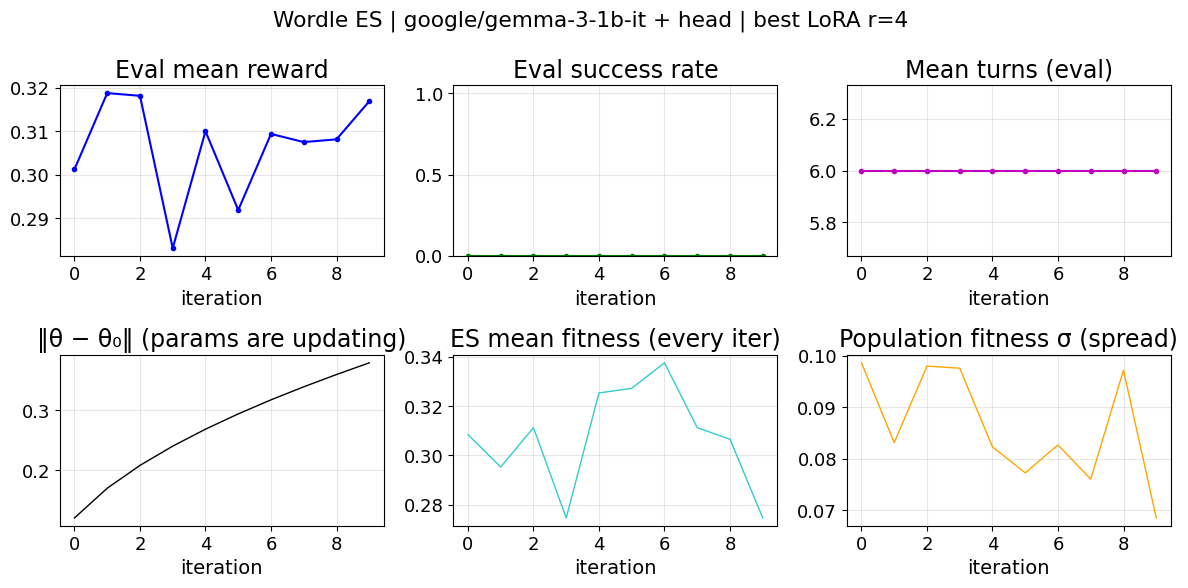

In [20]:
import matplotlib.pyplot as plt

it = history["iteration"]
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

axes[0, 0].plot(it, history["eval_reward"], "b-o", ms=3)
axes[0, 0].set_title("Eval mean reward")
axes[0, 0].set_xlabel("iteration")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(it, history["eval_success"], "g-o", ms=3)
axes[0, 1].set_title("Eval success rate")
axes[0, 1].set_xlabel("iteration")
axes[0, 1].set_ylim(0, 1.05)
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].plot(it, history["eval_turns"], "m-o", ms=3)
axes[0, 2].set_title("Mean turns (eval)")
axes[0, 2].set_xlabel("iteration")
axes[0, 2].grid(True, alpha=0.3)

ti = history["train_iter"]
axes[1, 0].plot(ti, history["param_drift"], "k-", lw=1)
axes[1, 0].set_title("‖θ − θ₀‖ (params are updating)")
axes[1, 0].set_xlabel("iteration")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(ti, history["train_fitness"], "c-", lw=1, alpha=0.8)
axes[1, 1].set_title("ES mean fitness (every iter)")
axes[1, 1].set_xlabel("iteration")
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].plot(ti, history["pop_fitness_std"], "orange", lw=1)
axes[1, 2].set_title("Population fitness σ (spread)")
axes[1, 2].set_xlabel("iteration")
axes[1, 2].grid(True, alpha=0.3)

rank_note = f" | best LoRA r={best_rank}" if "best_rank" in globals() else ""
plt.suptitle(f"Wordle ES | {MODEL_NAME} + head{rank_note}")
plt.tight_layout()
plt.show()

## 7. Save checkpoint (optional)

Saves the **head** plus `words` and `history` under `models/` at the repo root when `USE_LORA=False`.

When `USE_LORA=True`, checkpoint saving is skipped to avoid writing large LoRA model files.

In [21]:
# if USE_LORA:
#     if "best_rank" in globals():
#         print(f"Best LoRA rank selected from sweep: r={best_rank}")
#     print("Skipping checkpoint save for LoRA run to avoid large model artifacts.")
# else:
save_path = ROOT / "models" / f"wordle_gemma_es_head.{RUN_PROFILE}.pt"
save_path.parent.mkdir(parents=True, exist_ok=True)
payload = {
    "head": policy.head.state_dict(),
    "model_name": MODEL_NAME,
    "words": policy.words,
    "history": history,
    "use_lora": USE_LORA,
    "run_profile": RUN_PROFILE,
    "model_load_kwargs": {k: str(v) for k, v in MODEL_LOAD_KWARGS.items()},
}
if getattr(policy, "_lm_trainable", False):
    payload["lm"] = policy.lm.state_dict()
torch.save(payload, save_path)
print("Saved:", save_path)

Saved: /home/ubuntu/STAT-4830-project-base/models/wordle_gemma_es_head.gemma_full.pt


## 8. LoRA rank-sweep summary plots (hard / full-vocab)

These figures read from `rank_results` created in Section 5 (no metric recomputation).

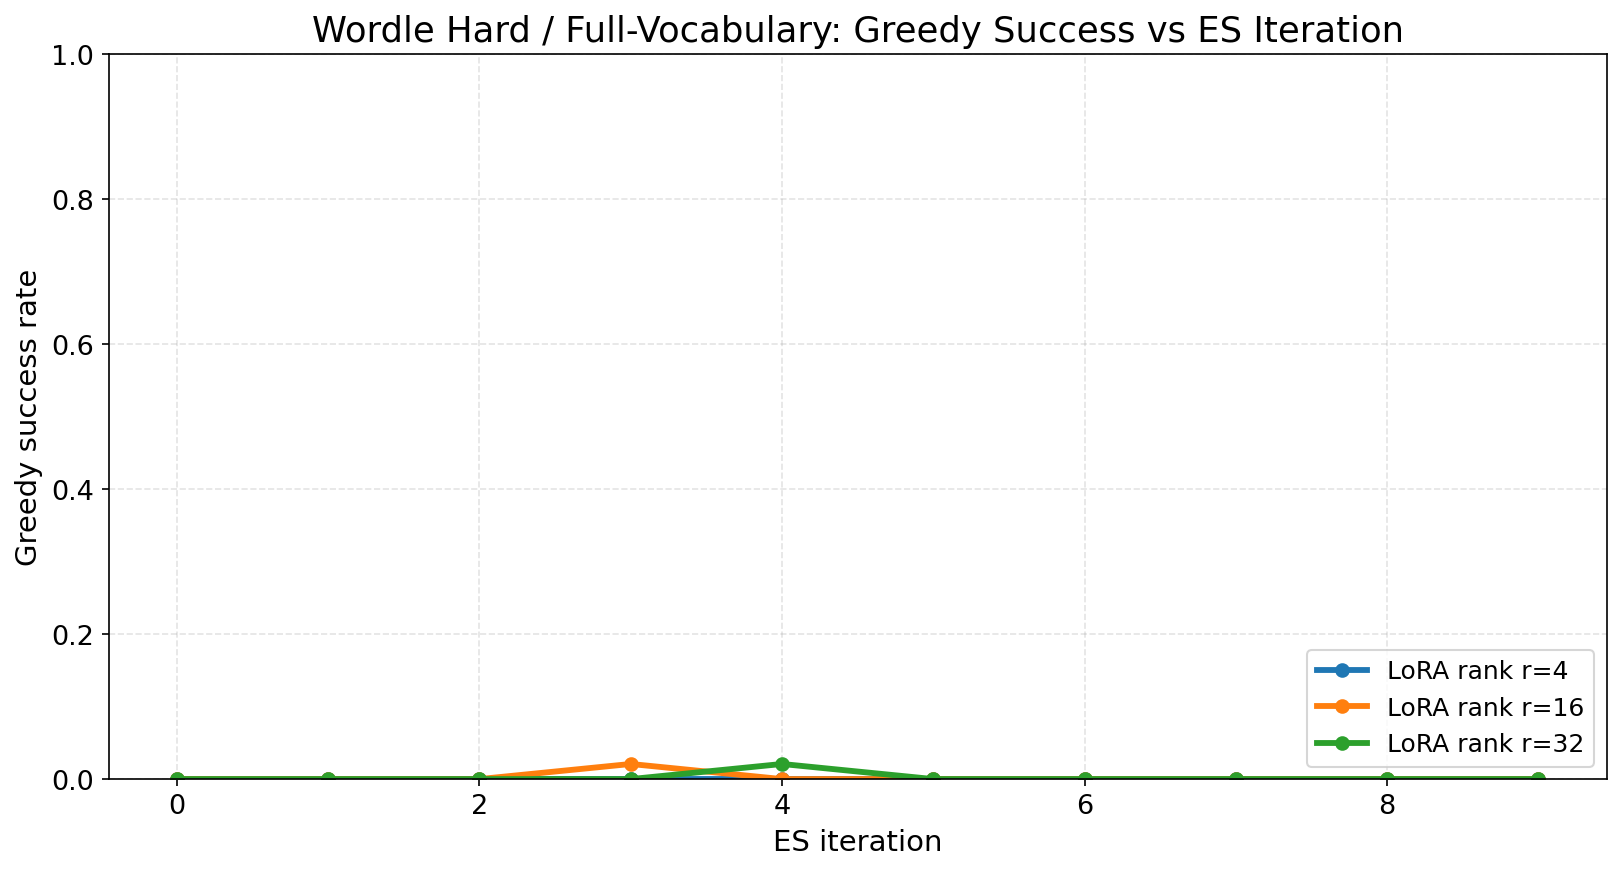

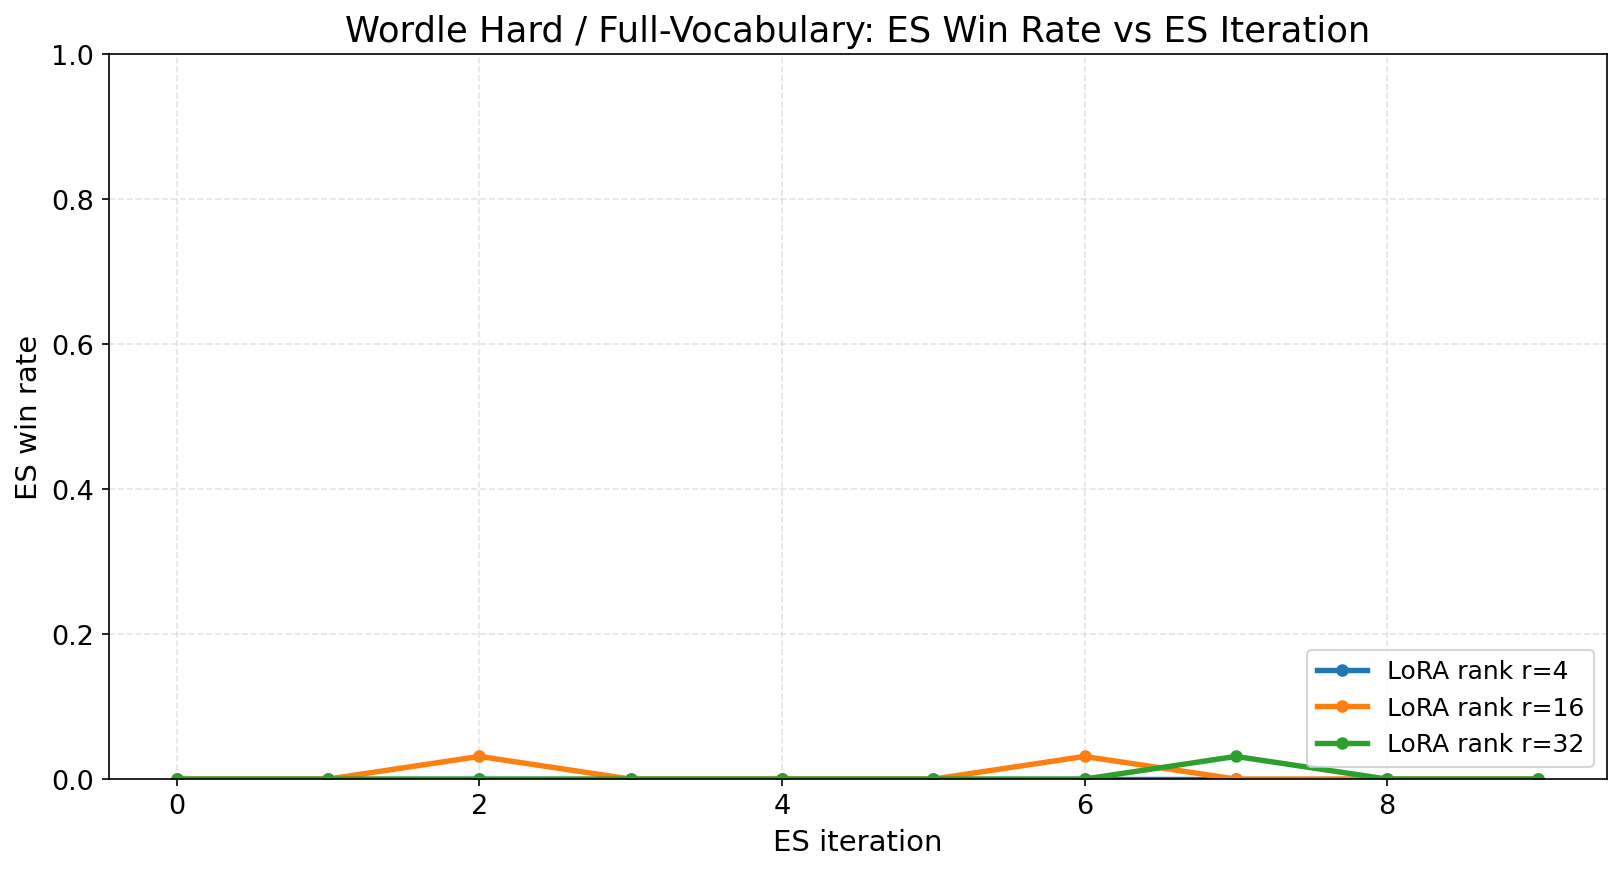

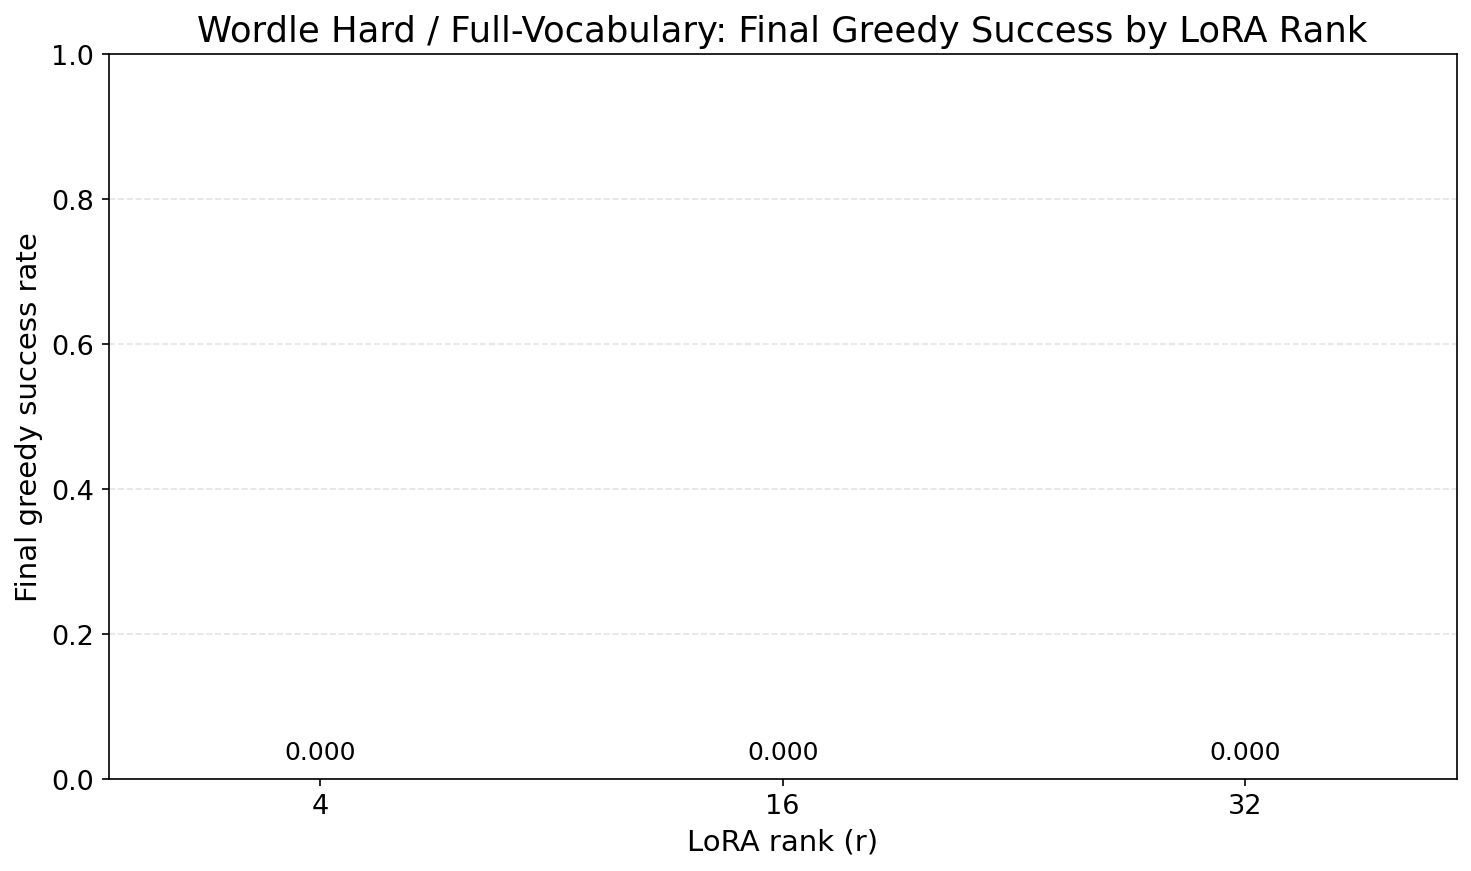

In [22]:
import matplotlib.pyplot as plt
import numpy as np

if "rank_results" not in globals() or not rank_results:
    raise RuntimeError("rank_results is missing. Run the LoRA rank-sweep training cell first.")

rank_order = [r for r in [4, 16, 32] if r in rank_results]
if len(rank_order) == 0:
    rank_order = sorted(rank_results.keys())

colors = {4: "#1f77b4", 16: "#ff7f0e", 32: "#2ca02c"}

plt.rcParams.update(
    {
        "font.size": 13,
        "axes.titlesize": 17,
        "axes.labelsize": 14,
        "legend.fontsize": 12,
    }
)

# 1) Main plot: greedy success rate vs ES iteration
fig, ax = plt.subplots(figsize=(11, 6), dpi=150)
for rank in rank_order:
    hist = rank_results[rank]["history"]
    x = hist["iteration"]
    y = hist["eval_success"]
    ax.plot(
        x,
        y,
        marker="o",
        linewidth=2.8,
        markersize=6,
        label=f"LoRA rank r={rank}",
        color=colors.get(rank, None),
    )

ax.set_title("Wordle Hard / Full-Vocabulary: Greedy Success vs ES Iteration")
ax.set_xlabel("ES iteration")
ax.set_ylabel("Greedy success rate")
ax.set_ylim(0.0, 1.0)
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend(loc="lower right", frameon=True)
fig.tight_layout()
plt.show()

# 2) Supporting plot: ES win rate vs ES iteration (if available)
has_es_win = all(
    "train_iter" in rank_results[r]["history"] and "train_es_win" in rank_results[r]["history"]
    for r in rank_order
)

if has_es_win:
    fig, ax = plt.subplots(figsize=(11, 6), dpi=150)
    for rank in rank_order:
        hist = rank_results[rank]["history"]
        ax.plot(
            hist["train_iter"],
            hist["train_es_win"],
            marker="o",
            linewidth=2.6,
            markersize=5,
            label=f"LoRA rank r={rank}",
            color=colors.get(rank, None),
        )

    ax.set_title("Wordle Hard / Full-Vocabulary: ES Win Rate vs ES Iteration")
    ax.set_xlabel("ES iteration")
    ax.set_ylabel("ES win rate")
    ax.set_ylim(0.0, 1.0)
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(loc="lower right", frameon=True)
    fig.tight_layout()
    plt.show()
else:
    print("Skipping ES win-rate support plot: 'train_iter'/'train_es_win' not found for all ranks.")

# 3) Final comparison bar chart: final greedy success by rank
final_success = [
    rank_results[r].get("final_success", float(rank_results[r]["history"]["eval_success"][-1]))
    for r in rank_order
]

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
bars = ax.bar(
    [str(r) for r in rank_order],
    final_success,
    color=[colors.get(r, "#4c78a8") for r in rank_order],
    width=0.65,
    alpha=0.95,
)

ax.set_title("Wordle Hard / Full-Vocabulary: Final Greedy Success by LoRA Rank")
ax.set_xlabel("LoRA rank (r)")
ax.set_ylabel("Final greedy success rate")
ax.set_ylim(0.0, 1.0)
ax.grid(axis="y", linestyle="--", alpha=0.35)

for bar, val in zip(bars, final_success):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        min(0.98, val + 0.02),
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=12,
    )

fig.tight_layout()
plt.show()